In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [2]:
c_df = pd.read_csv('C:\\Users\\ANJANA\\Desktop\\PyLibraries\\mock\\cleaned_datasets\\customer.csv')
p_df = pd.read_json('C:\\Users\\ANJANA\\Desktop\\PyLibraries\\mock\\cleaned_datasets\\product.json')
o_df = pd.read_excel('C:\\Users\\ANJANA\\Desktop\\PyLibraries\\mock\\cleaned_datasets\\orders.xlsx')

In [3]:
c_df.columns

Index(['customer_id', 'age', 'gender', 'occupation', 'married',
       'registered_date', 'premium_status', 'age_category'],
      dtype='str')

## 1.plot the no_of_customers based on age_category

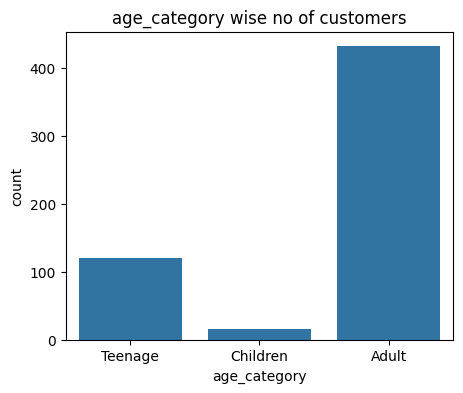

In [4]:
plt.figure(figsize=(5,4)) #(width, height)
sns.countplot(c_df, x='age_category')
plt.title('age_category wise no of customers')
# plt.ylabel('No of customers')
plt.show() # to hide <Axes: xlabel='age_category', ylabel='count'>

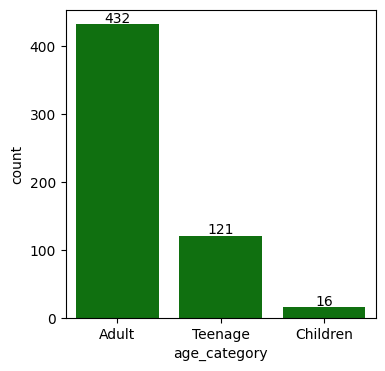

In [5]:
plt.figure(figsize=(4,4))
c=sns.countplot(c_df,x='age_category',order=['Adult','Teenage','Children'],color='green')
c.bar_label(c.containers[0],padding=-1)
plt.show()

**observation**
Adult customers are more in number followed by teen and children

## 2. plot the portion/percentage of marital_status

In [6]:
m=c_df['married'].value_counts()

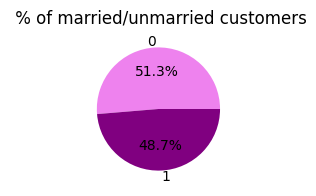

In [7]:
plt.figure(figsize=(2,2))
plt.pie(x=m.values,labels=m.index,autopct='%.1f%%',colors=['violet','purple'])  
plt.title(' % of married/unmarried customers')    
plt.show()

**observation**
unmarried customers are  more than married customers

## 3. plot the distribution of customers age

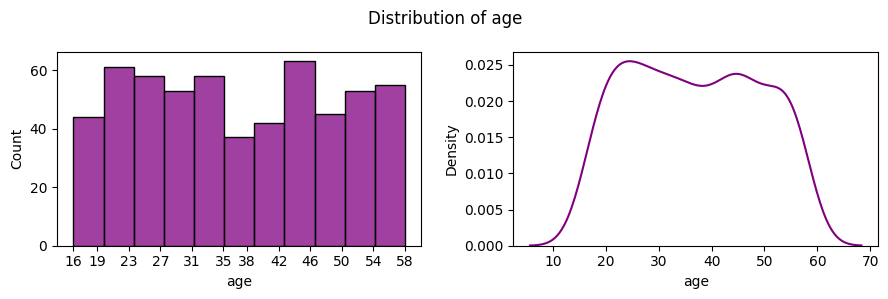

In [8]:
fig,axes=plt.subplots(1,2,figsize=(9,3))

sns.histplot(c_df,x='age',ax=axes[0],color='purple')
sns.kdeplot(c_df,x='age',ax=axes[1],color='purple')

plt.suptitle('Distribution of age')
plt.tight_layout()

axes[0].set_xticks(np.linspace(16,58,12,dtype=int))
plt.show()

**observation**

42-26 age customers are high in number followed by 19-23(age)

# 4. analyse the trend of new_registration

In [9]:
c_df.columns

Index(['customer_id', 'age', 'gender', 'occupation', 'married',
       'registered_date', 'premium_status', 'age_category'],
      dtype='str')

In [10]:
c_df['registered_date']=pd.to_datetime(c_df['registered_date'],errors='coerce')
temp= (c_df['registered_date'].dt.year).value_counts().sort_index()
temp    

registered_date
2017    10
2018    74
2019    75
2020    71
2021    75
2022    63
2023    75
2024    75
2025    51
Name: count, dtype: int64

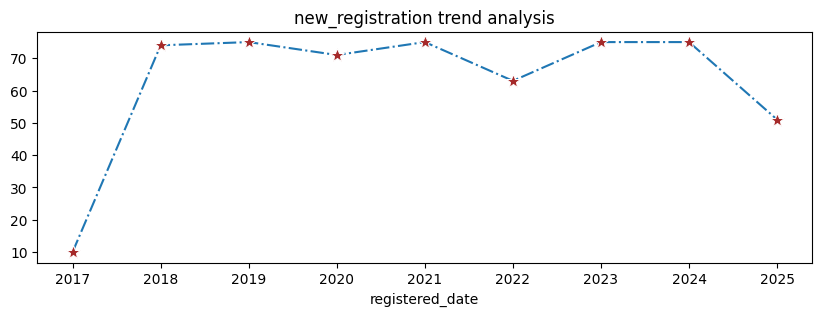

In [11]:
plt.figure(figsize=(10,3))
sns.lineplot(x=temp.index, y=temp.values,linestyle='-.',marker='*',markersize=10, markerfacecolor='brown')
plt.title('new_registration trend analysis')
plt.show()


In [12]:
# temp=(c_df['registered_date'].dt.year).value_counts().sort_index().reset_index()
# sns.lineplot(data=temp, x='registered_date', y='count')

# 5. (i) plot the relationship b/w price and ratings
#   (ii) plot the relationship b/w price and discounted amount

In [13]:
p_df.columns

Index(['product_id', 'price', 'discount', 'expiry_date', 'stock', 'ratings',
       'discounted amount', 'amazon', 'flipkart', 'product', 'category'],
      dtype='str')

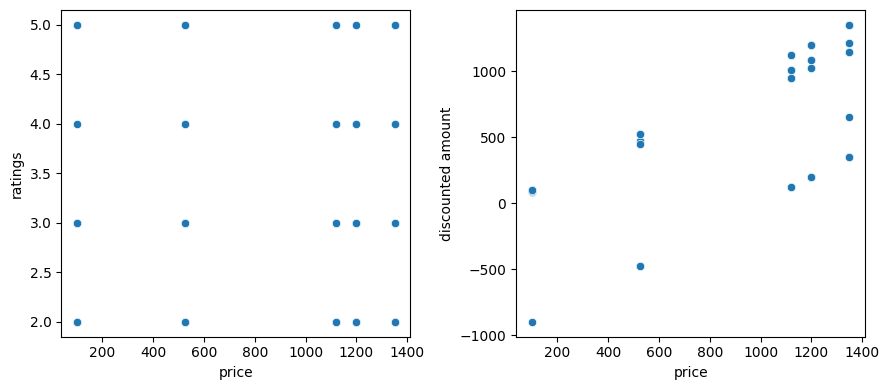

In [14]:
f,a= plt.subplots(1,2,figsize=(9,4)) #fifure,axes
sns.scatterplot(p_df, x='price', y='ratings',ax=a[0])
sns.scatterplot(p_df, x='price',y='discounted amount',ax=a[1])
plt.tight_layout()
plt.show()

# 6. (i) plot the corelationship b/w price and ratings
#   (ii) plot the corelationship b/w price and discounted amount

In [15]:
c=p_df.corr(numeric_only =True)

In [16]:
# cr=c[['price','ratings','discounted amount']]
# sns.heatmap(cr,annot=True)
# plt.show()

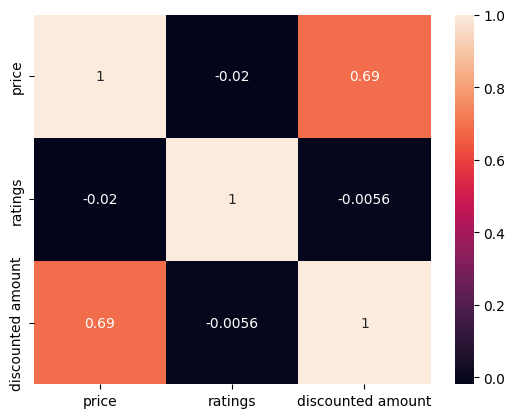

In [17]:
cr=c.loc[['price','ratings','discounted amount'],['price','ratings','discounted amount']]
sns.heatmap(cr,annot=True)
plt.show()


df.loc[ row_selection , column_selection]

df.loc[ row_conds , column_names]

df.loc[ row_indices , column_names]

In [18]:
o_df.columns

Index(['order_id', 'customer_id', 'product_id', 'order_date', 'net_quantity',
       'payment_mode', 'amount_saved', 'actual_total', 'amount_to_be_paid'],
      dtype='str')

# 7. plot the total revenue for each product_category

In [19]:
# temp = pd.merge(p_df[['product_id','stock','ratings']],
#                 o_df[['product_id','amount_to_be_paid']],
#                 how='inner',on='product_id')
# temp

temp = pd.merge(p_df[['product_id','category']],
                o_df[['product_id','amount_to_be_paid']],
                on='product_id')
temp



,product_id,category,amount_to_be_paid
0,P1003,Accessories,1400.0
1,P1003,Accessories,1050.0
2,P1003,Accessories,350.0
3,P1003,Accessories,1750.0
4,P1003,Accessories,1400.0
...,...,...,...
487,P1098,Hygiene,4080.0
488,P1098,Hygiene,5100.0
489,P1098,Hygiene,1020.0
490,P1098,Hygiene,1020.0


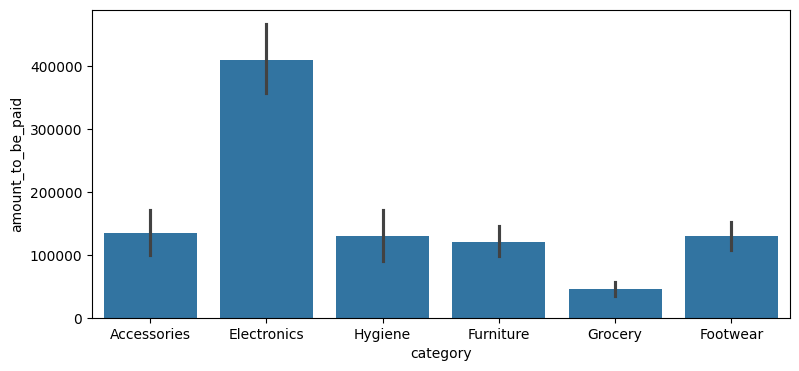

In [20]:
plt.figure(figsize=(9,4))
sns.barplot(data=temp, x='category', y='amount_to_be_paid', estimator=sum)
# it froups the category and applies summation on y axis(amount_to_be_paid)
plt.ylabel=('total revenue')
plt.show()


# 8. detect the outliers 

(i) amount_to_be_paid column

(ii) category wise amount_to_be_paid

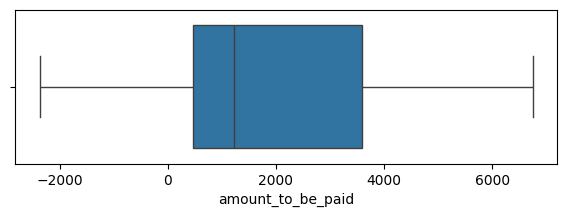

In [21]:
plt.figure(figsize=(7,2))
sns.boxplot(data=o_df,x='amount_to_be_paid')
plt.show()

In [22]:
temp=pd.merge(p_df[['product_id','category']],
         o_df[['product_id','amount_to_be_paid']],
         how='inner',on='product_id')

temp

,product_id,category,amount_to_be_paid
0,P1003,Accessories,1400.0
1,P1003,Accessories,1050.0
2,P1003,Accessories,350.0
3,P1003,Accessories,1750.0
4,P1003,Accessories,1400.0
...,...,...,...
487,P1098,Hygiene,4080.0
488,P1098,Hygiene,5100.0
489,P1098,Hygiene,1020.0
490,P1098,Hygiene,1020.0


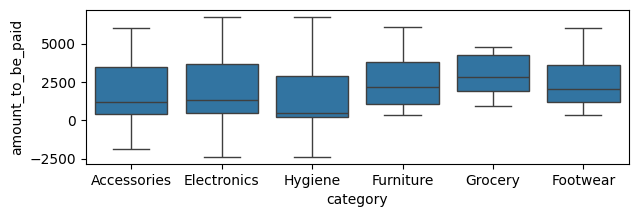

In [23]:
plt.figure(figsize=(7,2))
sns.boxplot(data=temp,y='amount_to_be_paid',x='category')
plt.show()

# 9. plot the relationship b/w amount_saved and actual_total along with their distribution

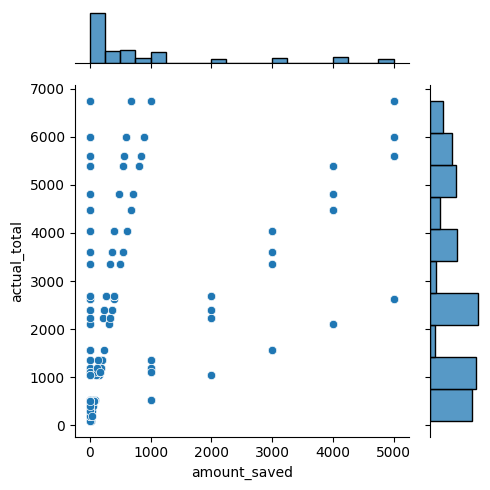

In [24]:
sns.jointplot(data=o_df,x='amount_saved',y='actual_total',height=5)
plt.tight_layout()
plt.show()

# 10. plot gender wise no_of_premium and non_premium customers

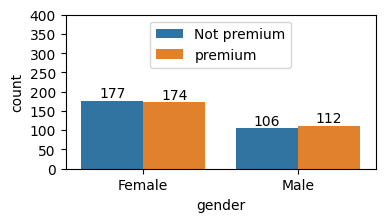

In [25]:
plt.figure(figsize=(4,2))
c=sns.countplot(c_df,x='gender',hue='premium_status')

for i in c.containers:
    c.bar_label(i)
plt.yticks([0,50,100,150,200,250,300,350,400])            #should not give unequal differences
plt.legend(labels=['Not premium','premium'],loc='upper center')
plt.show()

# 11. plot the gender wise avg_revenue for each product_category

In [26]:
temp = pd.merge(p_df[['product_id','category']],
                o_df[['customer_id','product_id','amount_to_be_paid']],
                how='inner',on='product_id')
temp=pd.merge(temp,c_df[['customer_id','gender']])


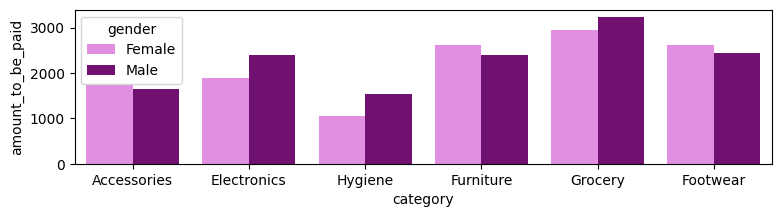

In [27]:
plt.figure(figsize=(9,2))
sns.barplot(data=temp,x='category',y='amount_to_be_paid',errorbar=None,estimator='mean',hue='gender',palette=['violet','purple'])

plt.show()

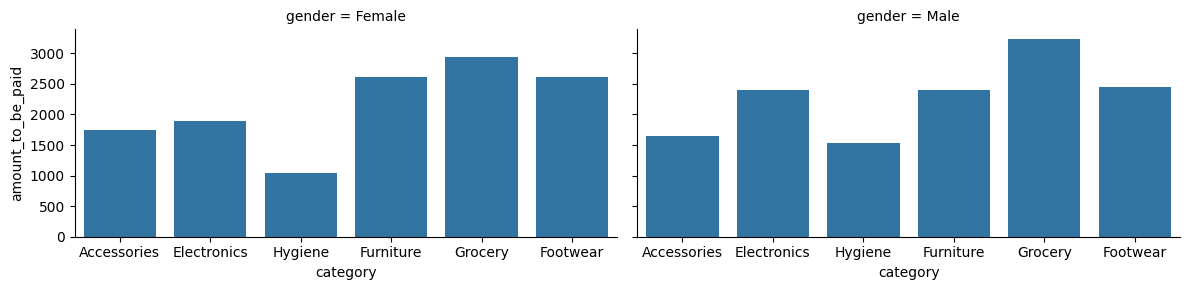

In [28]:
fg=sns.FacetGrid(temp,col='gender',height=3,aspect=2)               #width=height*aspect
fg.map_dataframe(sns.barplot,x='category',y='amount_to_be_paid',estimator='mean',errorbar=None)
plt.show()

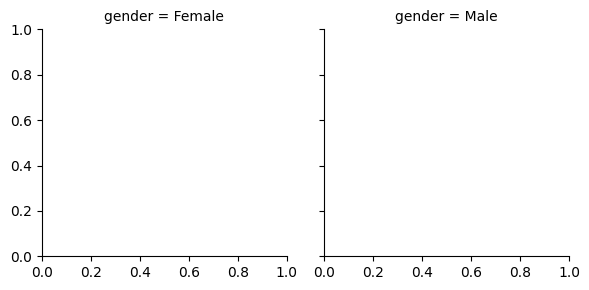

In [29]:
sns.FacetGrid(temp,col='gender')


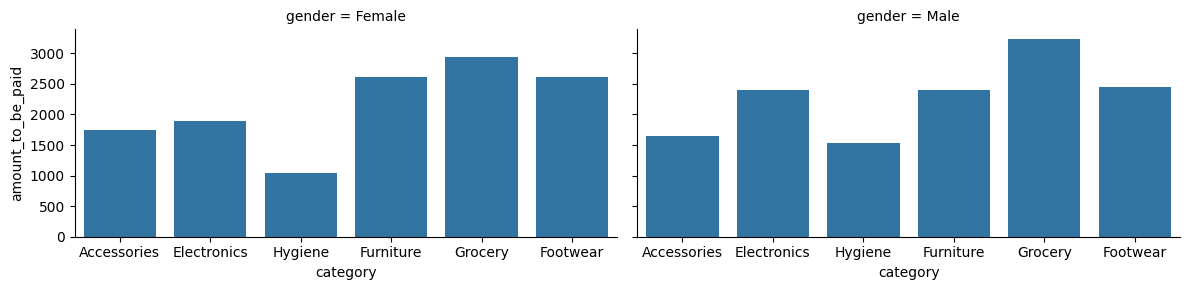

In [30]:
fg=sns.FacetGrid(temp,col='gender',height=3, aspect=2) #width=height*aspect
fg.map_dataframe(sns.barplot,x='category', y='amount_to_be_paid',estimator='mean',errorbar=None)
plt.show()